# Types of gradient descent
* **Batch Gradient Descent :-** Use all training samples for one forward pass and then adjust weights
* **Stochastic Gradient Descent :-** Use one (randomly picked) sample for a forward pass and then adjust weights
* **Mini batch gradient Descent :-** Use a batch of (randomly picked) samples for a forward pass and then adjust weights





# Loading data + preprocessing

In [7]:
import pandas as pd
import numpy as np
df = pd.read_csv('homeprices.csv')
df.head()

,area,bedrooms,price
0,1056,2,39.07
1,2600,4,120.00
2,1440,3,62.00
3,1521,3,75.00
4,1200,2,51.00


In [11]:
df.shape

(20, 3)

In [8]:
# Scaling the values
from sklearn.preprocessing import MinMaxScaler
x_scaled = MinMaxScaler()
y_scaled = MinMaxScaler()

scaled_x = x_scaled.fit_transform(df.drop('price', axis='columns'))
scaled_y = y_scaled.fit_transform(df['price'].values.reshape(-1,1))

In [9]:
scaled_y

array([[0.05237037],
       [0.65185185],
       [0.22222222],
       [0.31851852],
       [0.14074074],
       [0.04444444],
       [0.76296296],
       [0.91111111],
       [0.13333333],
       [1.        ],
       [0.37037037],
       [0.8       ],
       [0.04444444],
       [0.05925926],
       [0.51111111],
       [0.07407407],
       [0.11851852],
       [0.20740741],
       [0.51851852],
       [0.        ]])

In [10]:
# Converting target column to 1D
scaled_y = scaled_y.reshape(20,)
scaled_y

array([0.05237037, 0.65185185, 0.22222222, 0.31851852, 0.14074074,
       0.04444444, 0.76296296, 0.91111111, 0.13333333, 1.        ,
       0.37037037, 0.8       , 0.04444444, 0.05925926, 0.51111111,
       0.07407407, 0.11851852, 0.20740741, 0.51851852, 0.        ])

# Defining our own Batch gradient descent function

In [14]:
def batch_gradient_descent(X, y, epochs, learning_rate=0.01):
  no_of_features = X.shape[1]
  w = np.ones(shape=no_of_features)
  b = 0
  n = X.shape[0]

  cost_list = []
  epoch_list = []

  for i in range(epochs):
    y_predicted = np.dot(w, X.T) + b

    w_grad = -(2/n)*(X.T.dot(y-y_predicted))
    b_grad = -(2/n)*np.sum(y-y_predicted)

    w = w - learning_rate*w_grad
    b = b - learning_rate*b_grad

    cost = np.mean(np.square(y-y_predicted)) # MSE

    if i%10 == 0:
      cost_list.append(cost)
      epoch_list.append(i)

  return w, b, cost, cost_list, epoch_list

In [15]:
w, b, cost, cost_list, epoch_list = batch_gradient_descent(scaled_x, scaled_y, 500)
w, b, cost

(array([0.70712464, 0.67456527]),
 np.float64(-0.23034857438407427),
 np.float64(0.0068641890429808105))

### Plotting epoch vs cost graph to see how cost reduces as number of epoch increases

Text(0, 0.5, 'Cost')

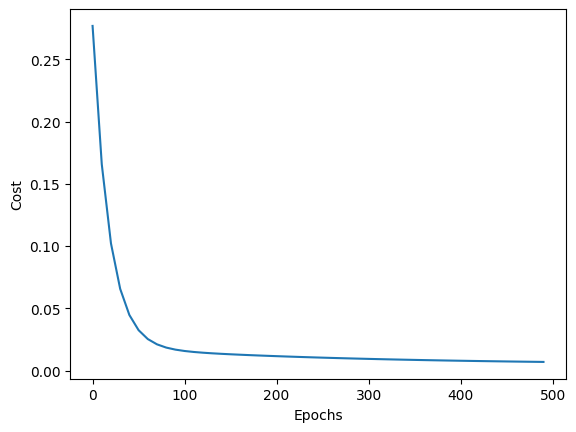

In [16]:
import matplotlib.pyplot as plt
plt.plot(epoch_list, cost_list)
plt.xlabel('Epochs')
plt.ylabel('Cost')

In [22]:
# Defining our own prediction function
def predict(area, bedrooms, w, b):
  scaled_x = x_scaled.transform([[area, bedrooms]])[0]
  scaled_price = w[0]*scaled_x[0] + w[1]*scaled_x[1] + b
  return y_scaled.inverse_transform([[scaled_price]])[0][0]

In [27]:
predict(2600, 4, w, b)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(128.45484403267596)

# Defining our own Stochastic gradient descent function

In [24]:
def stochastic_gradient_descent(X, y, epochs, learning_rate=0.01):
  no_of_features = X.shape[1]
  w = np.ones(shape=no_of_features)
  b = 0
  n = X.shape[0]

  cost_list = []
  epoch_list = []

  for i in range(epochs):
    import random
    random_index = random.randint(0, n-1)
    sample_x = X[random_index]
    sample_y = y[random_index]

    y_predicted = np.dot(w, sample_x.T) + b

    w_grad = -(2/n)*(sample_x.T.dot(sample_y-y_predicted))
    b_grad = -(2/n)*np.sum(sample_y-y_predicted)

    w = w - learning_rate*w_grad
    b = b - learning_rate*b_grad

    cost = np.square(sample_y-y_predicted)

    if i%100 == 0:
      cost_list.append(cost)
      epoch_list.append(i)

  return w, b, cost, cost_list, epoch_list

In [25]:
w_sgd, b_sgd, cost_sgd, cost_list_sgd, epoch_list_sgd = stochastic_gradient_descent(scaled_x, scaled_y, 10000)
w_sgd, b_sgd, cost_sgd

(array([0.70802398, 0.67360493]),
 np.float64(-0.23197584093448603),
 np.float64(0.006270106254352967))

### Plotting epoch vs cost graph to see how cost reduces as number of epoch increases

Text(0, 0.5, 'Cost')

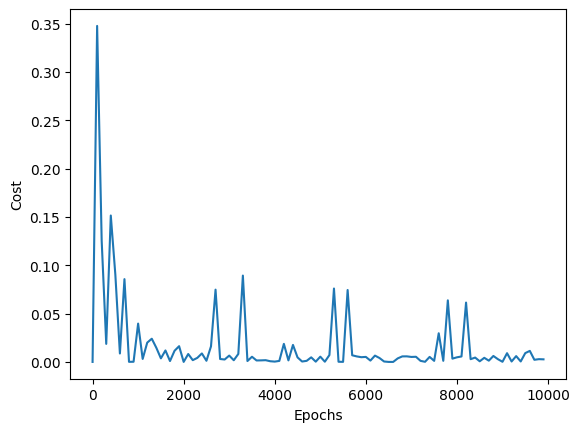

In [26]:
plt.plot(epoch_list_sgd, cost_list_sgd)
plt.xlabel('Epochs')
plt.ylabel('Cost')

In [28]:
predict(2600, 4, w_sgd, b_sgd)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(128.21328728133878)

# Defining our own mini batch gradient descent function

In [51]:
def mini_batch_gradient_descent(X, y, epochs, sample_size=5, learning_rate=0.01):
  no_of_features = X.shape[1]
  w = np.ones(shape=no_of_features)
  b = 0
  n = X.shape[0]
  m = sample_size

  cost_list = []
  epoch_list = []

  for i in range(epochs):
    indexes = np.random.choice(n, sample_size, replace=False)
    sample_x = X[indexes]
    sample_y = y[indexes]

    y_predicted = np.dot(w, sample_x.T) + b

    w_grad = -(2/m)*(sample_x.T.dot(sample_y-y_predicted))
    b_grad = -(2/m)*np.sum(sample_y-y_predicted)

    w = w - learning_rate*w_grad
    b = b - learning_rate*b_grad

    cost = np.mean(np.square(sample_y-y_predicted))

    if i%10 == 0:
      cost_list.append(cost)
      epoch_list.append(i)

  return w, b, cost, cost_list, epoch_list

In [52]:
w_mbgd, b_mbgd, cost_mbgd, cost_list_mbgd, epoch_list_mbgd = mini_batch_gradient_descent(scaled_x, scaled_y, 500)
w_mbgd, b_mbgd, cost_mbgd

(array([0.69883273, 0.67219685]),
 np.float64(-0.23239215678048097),
 np.float64(0.002397590549483998))

Text(0, 0.5, 'Cost')

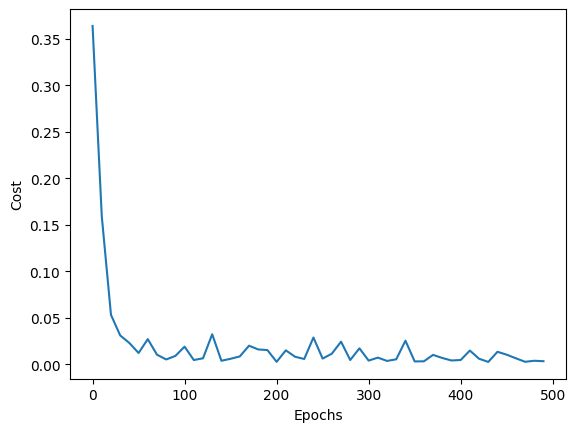

In [53]:
plt.plot(epoch_list_mbgd, cost_list_mbgd)
plt.xlabel('Epochs')
plt.ylabel('Cost')

In [54]:
predict(2600, 4, w_mbgd, b_mbgd)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(127.24435366569888)